# SHAP-Based Age Interaction Analysis

**Author:** Ali Farzaneh

This notebook investigates age-dependent associations between circulating microRNAs and incident heart failure using machine-learning and SHAP-based interaction analysis. An XGBoost survival model is used to capture potentially nonlinear relationships and interactions, and SHAP interaction values are used to quantify and rank interactions between age and individual microRNAs.

The analysis complements the Cox proportional hazards interaction analysis by providing a model-independent assessment of the relative importance and direction of age–microRNA interactions.

## Required Packages

In [1]:
import shap

import numpy as np
import pandas as pd
import random
import math
from datetime import datetime
from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, Normalize

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold


from sksurv.metrics import concordance_index_censored

import xgboost
import json
import sys

## Data Loading

In [2]:
xgb_dat = pd.read_csv("data/cox_dat.csv")
print(f"Dataset dimensions: {xgb_dat.shape}")


Dataset dimensions: (1897, 609)


In [3]:
# recoding the rs_cohort column values from 1/2 to 0/1
xgb_dat["rs_cohort"] = xgb_dat["rs_cohort"].map({1: 0, 2: 1})

# Categorical variables to be one-hot encoded
categorical_features = ["Wellcat", "smoking", "PlateNr"]
# One-hot encoding
xgb_dat = pd.get_dummies(
    xgb_dat,
    columns=categorical_features,
    drop_first=False,
    dtype=int
)

# Generated variables
encoded_columns = [
    col for col in xgb_dat.columns
    if col.startswith(("Wellcat_", "smoking_", "PlateNr_"))
]

print(encoded_columns)

['Wellcat_Center', 'Wellcat_Edge', 'Wellcat_Middle', 'smoking_0.0', 'smoking_1.0', 'smoking_2.0', 'PlateNr_1', 'PlateNr_2', 'PlateNr_3', 'PlateNr_4', 'PlateNr_5', 'PlateNr_6', 'PlateNr_7', 'PlateNr_8', 'PlateNr_9', 'PlateNr_10', 'PlateNr_11', 'PlateNr_12', 'PlateNr_13', 'PlateNr_14', 'PlateNr_15', 'PlateNr_16', 'PlateNr_17', 'PlateNr_18', 'PlateNr_19', 'PlateNr_20', 'PlateNr_21', 'PlateNr_22', 'PlateNr_23', 'PlateNr_24', 'PlateNr_25', 'PlateNr_26']


In [4]:
print(xgb_dat.groupby(['incident_hf']).size())


incident_hf
0    1581
1     316
dtype: int64


## Reading Age-Interacting microRNAs
The 21 microRNAs showing significant age-dependent associations with incident heart failure in the Cox interaction analysis were selected for the SHAP-based interaction analysis.

In [5]:
with open("results/21_miRNAs.txt", "r") as f:
    miRNAs = [line.strip() for line in f if line.strip()]

print(miRNAs[0:3])


['let_7f_5p', 'let_7i_5p', 'miR_103a_3p']


In [6]:
miRNAs_ids = ["hsa-" + x.replace("_", "-") for x in miRNAs]
print(miRNAs_ids[0:3])


['hsa-let-7f-5p', 'hsa-let-7i-5p', 'hsa-miR-103a-3p']


## Model Parameters and Covariates

In [7]:
params = {'objective': 'survival:cox',          
         'eval_metric': 'cox-nloglik',
         'verbosity': 0,
         'colsample_bytree': 0.9,
         'subsample': 0.9,
         'booster': 'gbtree',
         'lambda': 0.68,
         'alpha': 0.38,
         'n_estimators': 1000,
         'max_depth': 3,
         'min_child_weight': 5,
         'eta': 0.035,
         'gamma': 0.01}

In [8]:
# Covariates for fully adjusted xgb model
covariates = [
    "sex", "age", "bmi", "wbc_c", "rbc_c", "eGFR",
    "prevalent_dm", "HT", "tc", "hdl", 
    "lipid_reducing", "rs_cohort"
] + encoded_columns

print(f"Number of adjustment covariates: {len(covariates)}")
print(covariates)

Number of adjustment covariates: 44
['sex', 'age', 'bmi', 'wbc_c', 'rbc_c', 'eGFR', 'prevalent_dm', 'HT', 'tc', 'hdl', 'lipid_reducing', 'rs_cohort', 'Wellcat_Center', 'Wellcat_Edge', 'Wellcat_Middle', 'smoking_0.0', 'smoking_1.0', 'smoking_2.0', 'PlateNr_1', 'PlateNr_2', 'PlateNr_3', 'PlateNr_4', 'PlateNr_5', 'PlateNr_6', 'PlateNr_7', 'PlateNr_8', 'PlateNr_9', 'PlateNr_10', 'PlateNr_11', 'PlateNr_12', 'PlateNr_13', 'PlateNr_14', 'PlateNr_15', 'PlateNr_16', 'PlateNr_17', 'PlateNr_18', 'PlateNr_19', 'PlateNr_20', 'PlateNr_21', 'PlateNr_22', 'PlateNr_23', 'PlateNr_24', 'PlateNr_25', 'PlateNr_26']


## Repeated Cross-Validated SHAP Interaction Analysis


In [9]:
# Function to calculate cross-validated SHAP values and SHAP interaction values
# for each miRNA using a fully adjusted XGBoost survival model
def average_shap_calculator(idx):
    print("Round {0} : {1}".format(idx+1, miRNAs[idx]))
    miR_index = idx
    col_names = covariates + [miRNAs[miR_index]]
    y = xgb_dat[['incident_hf','obstime_hf']]
    x = xgb_dat.loc[:,col_names]
    Y2 = xgb_dat[['incident_hf']]
    
    # Repeated cross validation and SHAP values
    n_fold = 5   # up limit in i counter (inside loop)
    main_loop_counter = 10  # up limit in j counter (outside loop)
    all_round = n_fold * main_loop_counter
    r = n_fold    
    # Useing a dict to track the SHAP values of each observation per CV repitition 
    shap_values_per_cv = dict()
    for sample in x.index:
        ## Create keys for each sample
        shap_values_per_cv[sample] = {} 
        ## Then, keys for each CV fold within each sample
        for CV_repeat in range(main_loop_counter ):
            shap_values_per_cv[sample][CV_repeat] = {}
            
    # Useing a dict to track the interactions 
    shap_inter_per_cv = {}
    for sample in x.index:
        shap_inter_per_cv[sample] = {}
        for cv_repeat in range(main_loop_counter):
            shap_inter_per_cv[sample][cv_repeat] = {}
    
    for cv_repeat in range(0,main_loop_counter):
        # now = datetime.now()
        # current_time = now.strftime("%H:%M:%S")
        # print("Round {0} start at {1}".format(cv_repeat+1, current_time))
        # StratifiedKFold was used to have same distribution of events in folds 
        CV = StratifiedKFold(n_splits=5, shuffle=True, random_state = cv_repeat) 
         
        #produce and save 5 folds index 
        ix_training, ix_test = [], []
        # Loop through each fold and append the training & test indices to the empty lists above
        for fold in CV.split(x, Y2):
            ix_training.append(fold[0]), ix_test.append(fold[1]) 
    # XGBoost 
        for i, (train_outer_ix, test_outer_ix) in enumerate(zip(ix_training, ix_test)):
            xgb_model = xgboost.XGBRegressor(**params) 
            x_train, x_test = x.iloc[train_outer_ix, :], x.iloc[test_outer_ix, :]
            y_train, y_test =y.iloc[train_outer_ix,:], y.iloc[test_outer_ix,:]
    
            y_test_xgb = y_test['obstime_hf'].where(y_test['incident_hf']==1, -1 * y_test['obstime_hf'])
            y_train_xgb = y_train['obstime_hf'].where(y_train['incident_hf']==1, -1 * y_train['obstime_hf'])                
            y_test_xgb = np.asarray(y_test_xgb)
            
            xgb_model.fit(x_train, y_train_xgb)       
    
            explainer = shap.TreeExplainer(xgb_model)
            shap_v = explainer.shap_values(x_test)
            shap_inter = explainer.shap_interaction_values(x_test)
            # Extract SHAP information per fold per sample 
            for k, j in enumerate(test_outer_ix):            
                shap_values_per_cv[j][cv_repeat ] = shap_v[k] #-#-# * 5 + i
                shap_inter_per_cv[j][cv_repeat] = shap_inter[k] 
                
    # Average shap and interaction values from the repeated cross validation
    average_shap_values, stds, ranges = [],[],[]    
    for i in range(0,len(x)):
        df_per_obs = pd.DataFrame.from_dict(shap_values_per_cv[i]) # Get all SHAP values for sample number i
        # Get relevant statistics for every sample 
        average_shap_values.append(df_per_obs.mean(axis=1).values) 
        stds.append(df_per_obs.std(axis=1).values)
        ranges.append(df_per_obs.max(axis=1).values-df_per_obs.min(axis=1).values)
    # Aggregated shap interaction values
    average_shap_inter = []
    for i in x.index:
        mats = [mat for mat in shap_inter_per_cv[i].values() if isinstance(mat, np.ndarray)] 
        stacked = np.stack(mats, axis = 0)
        average_shap_inter.append(stacked.mean(axis = 0))
    average_shap_inter = np.array(average_shap_inter)  
    feature_names = x.columns
    return average_shap_inter, average_shap_values, feature_names

    

In [10]:
# Calling the average_shap_calculator function for all selected miRNAs and store the cross-validated SHAP and interaction results for each miRNA
results = {}
for i in range(len(miRNAs)):
    results[miRNAs[i]] =  average_shap_calculator(i)

Round 1 : let_7f_5p
Round 2 : let_7i_5p
Round 3 : miR_103a_3p
Round 4 : miR_107
Round 5 : miR_128_3p
Round 6 : miR_148a_3p
Round 7 : miR_148b_3p
Round 8 : miR_15b_5p
Round 9 : miR_191_5p
Round 10 : miR_199a_3p
Round 11 : miR_199a_5p
Round 12 : miR_20a_5p
Round 13 : miR_20b_5p
Round 14 : miR_21_5p
Round 15 : miR_335_5p
Round 16 : miR_33a_5p
Round 17 : miR_4433b_5p
Round 18 : miR_4655_3p
Round 19 : miR_590_5p
Round 20 : miR_6738_5p
Round 21 : miR_92b_3p


## Prepare Individual microRNA for SHAP Visualization

Select one microRNA and retrieve its corresponding SHAP interaction results for subsequent visualization.

In [11]:
miR_index = 0
col_names = covariates + [miRNAs[miR_index]]
x = xgb_dat.loc[:,col_names]


In [12]:
pretty_name = miRNAs_ids[miR_index]
miRNA     = miRNAs[miR_index]

average_shap_inter, average_shap_values, feature_names = results[miRNAs[miR_index]]

## Strong interaction values

In [13]:
def get_top_k_interactions(feature_names, shap_interactions, k):
    # Get the mean absolute contribution for each feature interaction
    aggregate_interactions = np.mean(np.abs(shap_interactions), axis=0)
    interactions = []
    for i in range(aggregate_interactions.shape[0]):
        for j in range(aggregate_interactions.shape[1]):
            if j < i:
                interactions.append(
                    (
                        feature_names[i] + "-" + feature_names[j],
                        aggregate_interactions[i][j] * 2,
                    )
                )
    # sort by magnitude
    interactions.sort(key=lambda x: x[1], reverse=True)
    # interaction_features, interaction_values = map(tuple, zip(*interactions))
    return interactions[:k]

    # return interaction_features[:k], interaction_values[:k]

In [14]:
top10 = get_top_k_interactions(feature_names, average_shap_inter, 10)
for feat_pair, strength in top10:
    print(f"{feat_pair}: {strength:.4f}")

bmi-age: 0.1123
let_7f_5p-age: 0.0950
hdl-eGFR: 0.0763
eGFR-bmi: 0.0750
rbc_c-bmi: 0.0722
rbc_c-age: 0.0716
let_7f_5p-bmi: 0.0699
tc-rbc_c: 0.0660
wbc_c-age: 0.0659
eGFR-age: 0.0642


In [15]:
# Directory for SHAP analysis outputs
shap_results_dir = "results/SHAP_results"

import os
os.makedirs(shap_results_dir, exist_ok=True)

In [16]:
all_row = []
for mir in miRNAs:
    average_shap_inter, average_shap_values, feature_names = results[mir]
    top10 = get_top_k_interactions(feature_names, average_shap_inter, 10)
    for interaction_name, interaction_strength in top10:
        all_row.append({
            'miRNA': mir,
            'interaction' : interaction_name,
            'strength' : float(interaction_strength)            
        })
df_interaction = pd.DataFrame(all_row)
df_interaction.to_csv(shap_results_dir +'/interaction_strength.csv', index=False, header = True, sep=',')
df_interaction.head()

,miRNA,interaction,strength
0,let_7f_5p,bmi-age,0.112320
1,let_7f_5p,let_7f_5p-age,0.095009
2,let_7f_5p,hdl-eGFR,0.076284
3,let_7f_5p,eGFR-bmi,0.074962
4,let_7f_5p,rbc_c-bmi,0.072232


## Visualize Age–microRNA SHAP Interactions

SHAP dependence plots were generated for the 21 selected microRNAs to visualize their interactions with age. Each panel displays the SHAP interaction value for a microRNA-age pair across participants, with points colored by age. A common age color scale was applied across all panels to facilitate comparison.

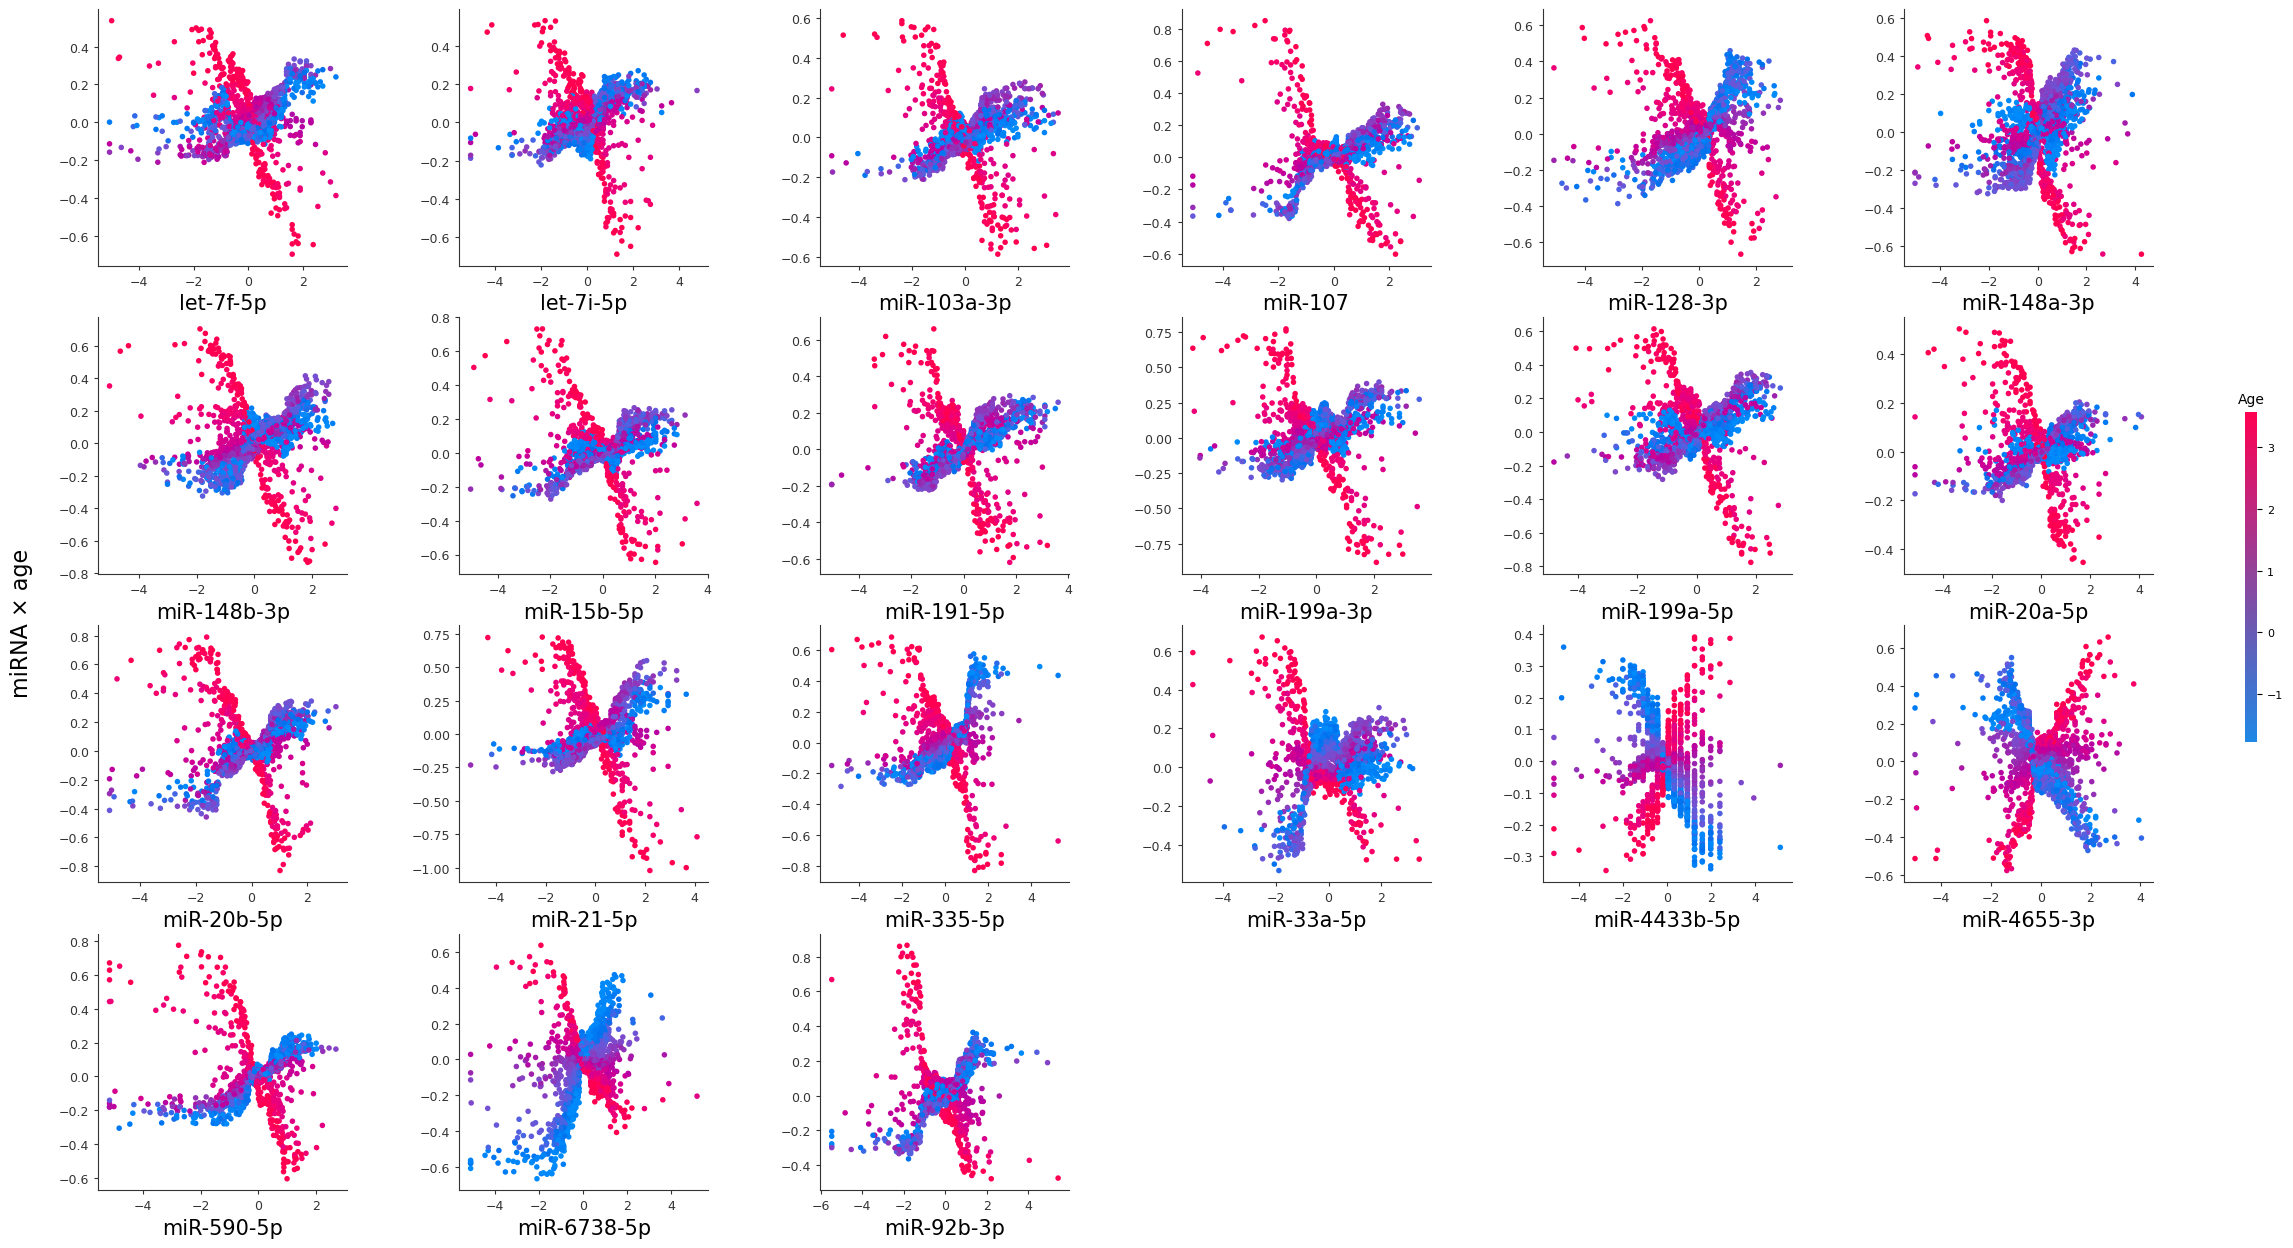

In [18]:
n = len(miRNAs)
n_cols = 6
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.2 * n_cols, 3.3 * n_rows) #,
    #dpi=350
)
axes = np.array(axes).reshape(n_rows, n_cols)

for idx, miR in enumerate(miRNAs):
    r = idx // n_cols
    c = idx % n_cols
    ax = axes[r, c]

    plt.sca(ax)

    col_names = covariates + [miR]
    x = xgb_dat.loc[:, col_names]
    average_shap_inter, average_shap_values, feature_names = results[miR]

    shap.dependence_plot(
        (miR, "age"),
        average_shap_inter,
        x,
        display_features=x,
        show=False,
        ax=ax
    )

    while len(fig.axes) > n_rows * n_cols:
        fig.axes[-1].remove()

    ax.set_xlabel(miR.replace("_", "-"), fontsize=15, color="black")
    ax.set_ylabel("")
    ax.set_title("")
    ax.tick_params(axis="both", labelsize=9, width=0.8, length=3)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

# Remove unused axes completely
for j in range(n, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    fig.delaxes(axes[r, c])

# Global label
fig.text(0.02, 0.5, "miRNA × age", va="center", rotation="vertical", fontsize=16)

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=shap_cmap, norm=norm)
sm.set_array([])

cbar_ax = fig.add_axes([0.907, 0.41, 0.0048, 0.25])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.ax.set_title("Age", fontsize=10, pad=6)
cbar.ax.tick_params(labelsize=8)
cbar.outline.set_visible(False)

for spine in cbar_ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(
    left=0.055,
    right=0.895,
    bottom=0.07,
    top=0.965,
    wspace=0.16,
    hspace=0.20
)
plt.savefig(
    shap_results_dir + "/all_miRNA_interaction_plots_globalcolorbar_2_400.tif",
    dpi=400,              # or 350 if that's the journal minimum
    bbox_inches="tight",
    format="tiff",
    pil_kwargs={"compression": "tiff_lzw"}
)
plt.savefig(
    shap_results_dir + "/all_miRNA_interaction_plots_globalcolorbar_2_400.jpeg" ,
    dpi= 400
)
plt.show()

## Session Information

The Python version and operating system

In [19]:
print("Python version:")
print(sys.version)

print("\nPlatform:")
print(platform.platform())

Python version:
3.13.13 | packaged by conda-forge | (main, Apr  8 2026, 01:56:49) [MSC v.1944 64 bit (AMD64)]

Platform:
Windows-11-10.0.26200-SP0
